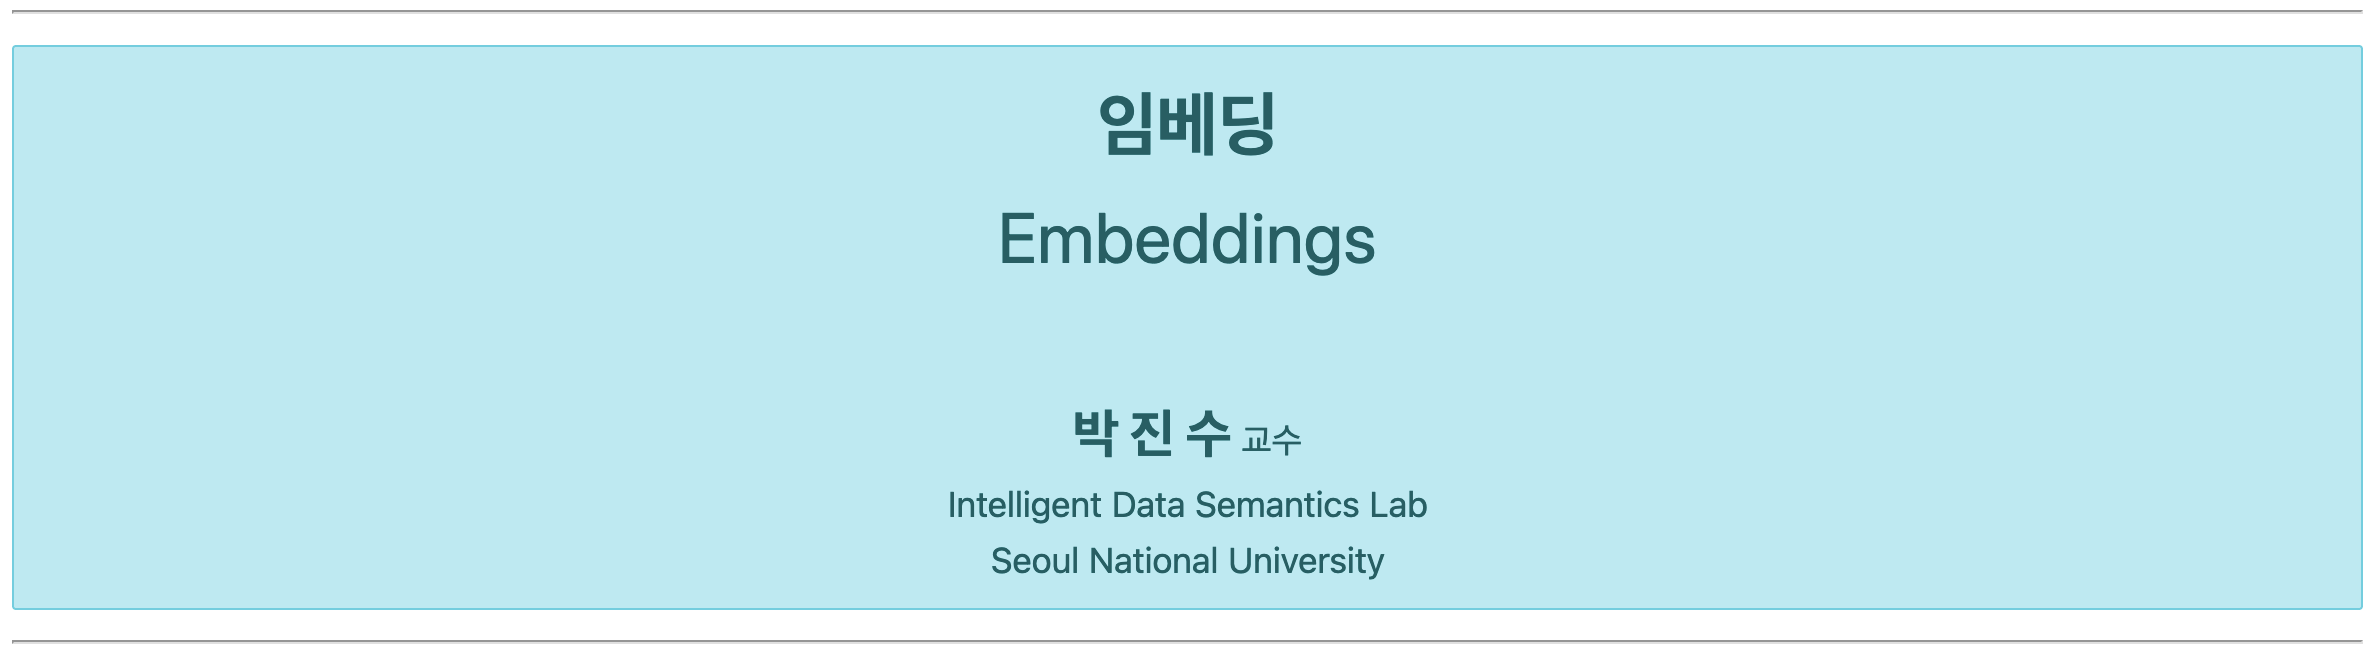

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#임베딩(embeddings)" data-toc-modified-id="임베딩(embeddings)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>임베딩(embeddings)</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU pandas seaborn # YOUR LLM package HERE(e.g., openai, ollama, etc.)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


# 임베딩(embeddings)

- - - 
**임베딩 벡터**
- 임베딩 벡터는 문장의 내용이 뜻하는 것을 수치화하여 기계가 이해할 수 있도록 하는 고차원 공간의 숫자 배열이다.
- 비슷한 내용의 텍스트는 비슷한 벡터를 갖는다.
- 임베딩 벡터로 표현한 정보를 저장하려면 벡터 저장소를 사용한다.
- - -

- - -
**오픈 소스 임베딩 모델을 사용하는 경우**
- Ollama 서버가 실행 중인지 확인한다.
- 실습에 필요한 임베딩 모델을 본인의 로컬 컴퓨터로 내려받는다.
    + **> ollama pull nomic-embed-text**를 통해 모델 가져오기
- - -

In [2]:
from langchain_ollama import OllamaEmbeddings
from langchain_openai import OpenAIEmbeddings


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

embeddings = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
sentence1 = '나는 강아지를 좋아합니다.'
sentence2 = '나는 고양이를 좋아합니다.'
sentence3 = '나는 드럼을 좋아합니다.'

In [ ]:
embedding1 = embeddings.embed_query(sentence1)
embedding2 = embeddings.embed_query(sentence2)
embedding3 = embeddings.embed_query(sentence3)

In [6]:
print(len(embedding1), len(embedding2), len(embedding3))

3072 3072 3072


In [8]:
print(embedding1[:10], '\n')
print(embedding2[:10], '\n')
print(embedding3[:10], '\n')

[-0.03753439709544182, -0.016552185639739037, -0.0008551711216568947, 0.004855408798903227, 0.012796732597053051, 0.041078418493270874, -0.01096431352198124, -0.01078308466821909, -0.010380355641245842, -0.011135472916066647] 

[-0.01239094790071249, -0.020146306604146957, -0.005613822024315596, 0.009641320444643497, 0.026720736175775528, 0.05372348427772522, -0.02932935580611229, -0.007654010318219662, 0.00216136546805501, -0.03608004376292229] 

[0.01638958975672722, -0.03908985108137131, -0.004857855848968029, 0.005337398964911699, -0.02447088249027729, 0.05402662232518196, -0.031780365854501724, 0.00762728787958622, 0.0032972129993140697, -0.014323865063488483] 



In [9]:
import numpy

def cosine_similarity(v1, v2):
    dot_product = numpy.dot(v1, v2)
    norm_v1 = numpy.linalg.norm(v1)
    norm_v2 = numpy.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

print(cosine_similarity(embedding1, embedding2))
print(cosine_similarity(embedding1, embedding3))
print(cosine_similarity(embedding2, embedding3))

0.6884185654770028
0.4956463602343638
0.49361775680233294


In [11]:
# 기본적인 한글 폰트가 설치되었다고 가정하고 운영 시스템에 따라 기본 한글 폰트를 설정한다.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS면
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # 윈도우면
    rc('font', family='Malgun Gothic')
else:
    print('ERROR: 시스템 운영체제를 확인할 수 없어 한글 폰트 설정에 실패하였습니다.') 

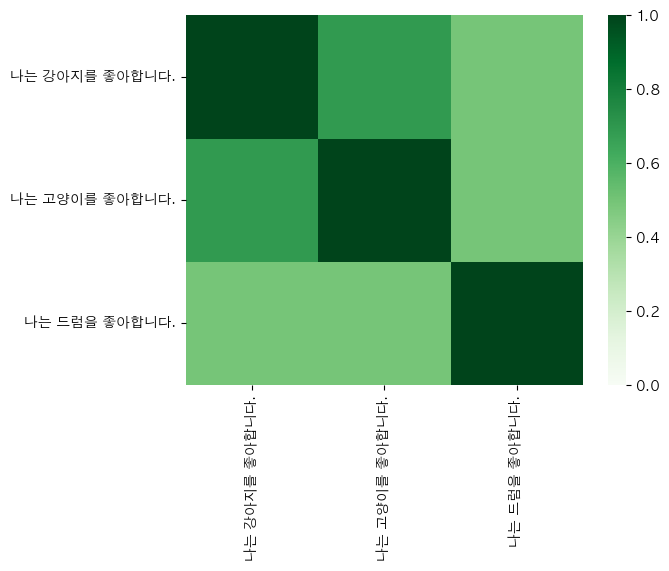

In [12]:
import pandas, seaborn 

df = pandas.DataFrame([embedding1, embedding2, embedding3], index=[sentence1, sentence2, sentence3])
sim = df @ df.T
seaborn.heatmap(sim, vmin=0, vmax=1, cmap='Greens');

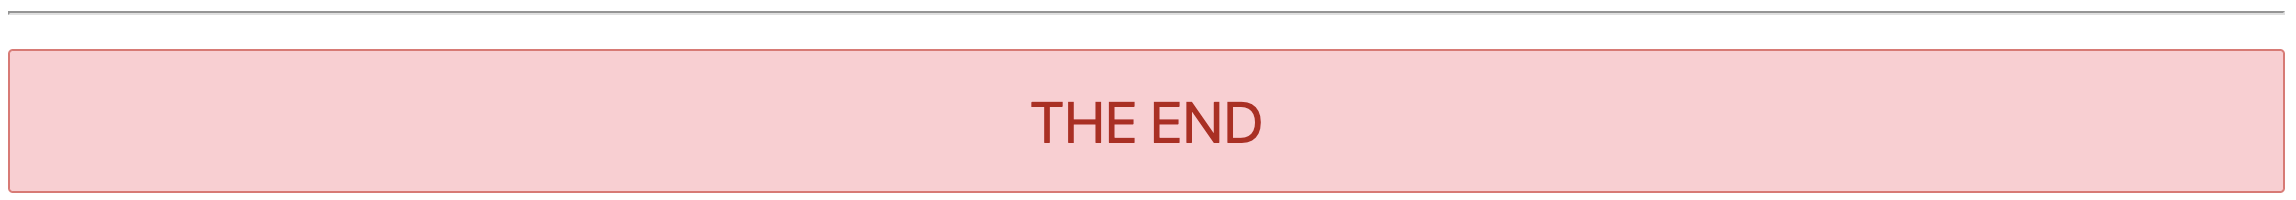